In [17]:
import time
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

## Playing with Tensors in PyTorch

- Creating tensors → torch.tensor() or torch.arange()

- Basic math → element-wise operations (+, -, *, /)

- Matrix math → torch.matmul() vs element-wise *

- Reshaping → .view() to change tensor shape

- GPU acceleration → moving tensors to CUDA

In [81]:
import torch

# 1. Create tensors
a = torch.tensor([1, 2, 3, 4])
b = torch.tensor([10, 20, 30, 40])

print("Tensor a:", a)
print("Tensor b:", b)

# 2. Basic operations
print("\nAddition:", a + b)
print("Subtraction:", a - b)
print("Multiplication:", a * b)
print("Division:", b / a)

# 3. Matrix operations
mat1 = torch.tensor([[1, 2], [3, 4]])
mat2 = torch.tensor([[5, 6], [7, 8]])

print("\nMatrix 1:\n", mat1)
print("Matrix 2:\n", mat2)

print("Matrix multiplication:\n", torch.matmul(mat1, mat2))
print("Element-wise multiplication:\n", mat1 * mat2)

# 4. Reshaping tensors
x = torch.arange(12)   # creates a tensor [0, 1, 2, ..., 11]
print("\nOriginal x:", x)

x_reshaped = x.view(3, 4)  # reshape into 3 rows, 4 columns
print("Reshaped x (3x4):\n", x_reshaped)

# 5. Using GPU (if available)
if torch.cuda.is_available():
    x_gpu = x.to("cuda")
    print("\nTensor on GPU:", x_gpu)

Tensor a: tensor([1, 2, 3, 4])
Tensor b: tensor([10, 20, 30, 40])

Addition: tensor([11, 22, 33, 44])
Subtraction: tensor([ -9, -18, -27, -36])
Multiplication: tensor([ 10,  40,  90, 160])
Division: tensor([10., 10., 10., 10.])

Matrix 1:
 tensor([[1, 2],
        [3, 4]])
Matrix 2:
 tensor([[5, 6],
        [7, 8]])
Matrix multiplication:
 tensor([[19, 22],
        [43, 50]])
Element-wise multiplication:
 tensor([[ 5, 12],
        [21, 32]])

Original x: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Reshaped x (3x4):
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


## Broadcasting rules

When PyTorch tries to add A + B:

It compares shapes from right to left (last dimension → backwards).

Dimensions are compatible if:

They are equal, OR

One of them is 1.

If one is 1, PyTorch automatically stretches (broadcasts) it to match the other.

##  Simulating a Neural Network Layer

- Simulate a single fully connected layer (like in a neural net).

- Create some input data (like student scores).

- Define weights and biases manually (like a layer in PyTorch).

- Use tensor operations to compute outputs.

In [82]:
import torch

# 1. Input data (batch of 3 students, each with 4 features: [math, science, english, history])
inputs = torch.tensor([
    [90.0, 80.0, 70.0, 85.0],   # Student 1
    [60.0, 65.0, 75.0, 70.0],   # Student 2
    [100.0, 95.0, 85.0, 90.0]   # Student 3
])

print("Input shape:", inputs.shape)  # (3, 4)

# 2. Define weights & biases (like layer params)
# Layer: 4 inputs -> 2 outputs (maybe: scholarship_score, dropout_risk)
weights = torch.randn(4, 2)  # random weights
bias = torch.randn(2)        # bias for each output

print("\nWeights:\n", weights)
print("Bias:\n", bias)

# 3. Forward pass (matrix multiplication + bias)
outputs = torch.matmul(inputs, weights) + bias
print("\nLayer outputs:\n", outputs)

# 4. Apply activation function (ReLU here: max(0, x))
activated = torch.relu(outputs)
print("\nActivated outputs (ReLU):\n", activated)


Input shape: torch.Size([3, 4])

Weights:
 tensor([[ 0.7711, -1.1475],
        [ 0.2523,  1.2197],
        [ 1.9374, -0.6601],
        [ 0.6255, -1.7546]])
Bias:
 tensor([-0.7397,  0.5611])

Layer outputs:
 tensor([[ 277.6212, -200.4812],
        [ 251.0106, -161.3342],
        [ 321.3045, -212.3344]])

Activated outputs (ReLU):
 tensor([[277.6212,   0.0000],
        [251.0106,   0.0000],
        [321.3045,   0.0000]])


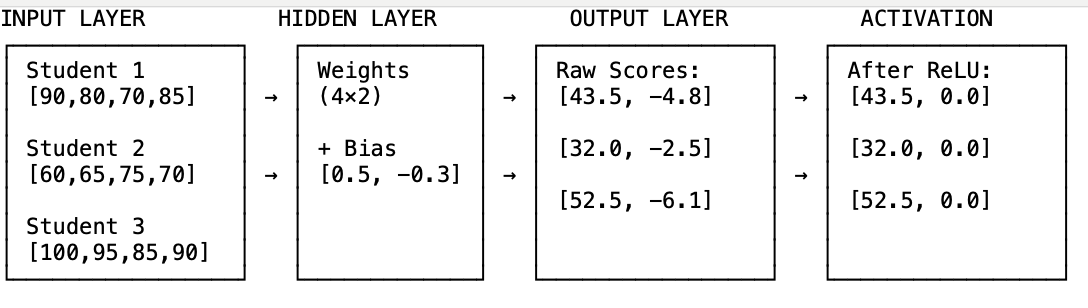

##  Diabetes Example Simulating NN

In [11]:
b1 = torch.zeros((1, 4), requires_grad=True)  # bias for hidden
b1.shape
#print(b1)

torch.Size([1, 4])

In [7]:
print(X @ W1)

tensor([[  3.9158,   6.8496,  68.5097,   5.5424],
        [ -1.1378,   6.3757,  82.9313,   2.8661],
        [ 16.8179,  13.7316, 101.4154,  15.4100],
        [ 14.5705,  14.0880, 114.8010,  14.5234],
        [ 11.2086,  10.6126,  85.5487,  11.0520]], grad_fn=<MmBackward0>)


In [12]:
b1 = torch.tensor([
    [1, 2, 3, 100]])
b1.shape

torch.Size([1, 4])

In [13]:
print(X @ W1 + b1)

tensor([[  4.9158,   8.8496,  71.5097, 105.5424],
        [ -0.1378,   8.3757,  85.9313, 102.8661],
        [ 17.8179,  15.7316, 104.4154, 115.4100],
        [ 15.5705,  16.0880, 117.8010, 114.5234],
        [ 12.2086,  12.6126,  88.5487, 111.0520]], grad_fn=<AddBackward0>)


In [15]:
import torch

# 1. Fake dataset (glucose, BMI → diabetes yes/no)
X = torch.tensor([
    [85.0, 22.0],
    [90.0, 28.0],
    [150.0, 30.0],
    [160.0, 35.0],
    [120.0, 26.0],
])

y = torch.tensor([[0.0], [0.0], [1.0], [1.0], [1.0]])

# 2. Define model parameters manually
torch.manual_seed(42)
W1 = torch.randn((2, 4), requires_grad=True)  # input → hidden (2x4)
b1 = torch.zeros((1, 4), requires_grad=True)  # bias for hidden

W2 = torch.randn((4, 1), requires_grad=True)  # hidden → output (4x1)
b2 = torch.zeros((1, 1), requires_grad=True)  # bias for output

# Sigmoid activation
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

# ReLU activation
def relu(x):
    return torch.maximum(torch.zeros_like(x), x)

# Binary Cross Entropy Loss
def bce_loss(y_pred, y_true):
    eps = 1e-7  # for numerical stability
    return -torch.mean(
        y_true * torch.log(y_pred + eps) + (1 - y_true) * torch.log(1 - y_pred + eps)
    )

# 3. Training loop
lr = 0.001
for epoch in range(5000):

    # Forward pass
    test = X @ W1
    #print("size of test is", test.shape)

    hidden = relu(X @ W1 + b1)      # input → hidden
    #print("size of hiddedn is", hidden.shape)
    out = sigmoid(hidden @ W2 + b2) # hidden → output
    #print("size of output is", out.shape)


    loss = bce_loss(out, y)

    # Backpropagation
    loss.backward()

    # Gradient descent update
    with torch.no_grad():
        W1 -= lr * W1.grad
        b1 -= lr * b1.grad
        W2 -= lr * W2.grad
        b2 -= lr * b2.grad

    # Zero the gradients
    W1.grad.zero_()
    b1.grad.zero_()
    W2.grad.zero_()
    b2.grad.zero_()

    # Print every 1000 epochs
    if (epoch+1) % 1000 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# 4. Testing
with torch.no_grad():
    test_patient = torch.tensor([[140.0, 32.0]])
    hidden = relu(test_patient @ W1 + b1)
    pred = sigmoid(hidden @ W2 + b2)

    print("\nTest Prediction (probability of diabetes):", pred.item())
    print("Predicted class:", 1 if pred.item() > 0.5 else 0)


Epoch 1000, Loss: 6.4472
Epoch 2000, Loss: 6.4472
Epoch 3000, Loss: 6.4472
Epoch 4000, Loss: 6.4472
Epoch 5000, Loss: 6.4472

Test Prediction (probability of diabetes): 1.0
Predicted class: 1


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Fake dataset (glucose, BMI → diabetes yes/no)
X = torch.tensor([
    [85.0, 22.0],   # normal glucose, healthy BMI → likely healthy
    [90.0, 28.0],   # slightly high BMI → healthy
    [150.0, 30.0],  # high glucose, overweight → diabetic
    [160.0, 35.0],  # very high glucose, obese → diabetic
    [120.0, 26.0],  # borderline glucose, overweight → maybe diabetic
])

y = torch.tensor([[0.0], [0.0], [1.0], [1.0], [1.0]])  # labels

# 2. Simple 2-layer neural network
class DiabetesNN(nn.Module):
    def __init__(self):
        super(DiabetesNN, self).__init__()
        self.layer1 = nn.Linear(2, 4)  # 2 inputs → 4 hidden neurons
        self.layer2 = nn.Linear(4, 1)  # hidden → output
    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.sigmoid(self.layer2(x))  # probability between 0 and 1
        return x

model = DiabetesNN()

# 3. Loss + Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

# 4. Training loop
for epoch in range(200):
    outputs = model(X)
    loss = criterion(outputs, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 50 == 0:
        print(f"Epoch [{epoch+1}/200], Loss: {loss.item():.4f}")

# 5. Test the model
with torch.no_grad():
    test_patient = torch.tensor([[140.0, 32.0]])  # high glucose, overweight
    prediction = model(test_patient)
    print("\nTest Prediction (probability of diabetes):", prediction.item())
    print("Predicted class:", 1 if prediction.item() > 0.5 else 0)


Epoch [50/200], Loss: 0.6731
Epoch [100/200], Loss: 0.6730
Epoch [150/200], Loss: 0.6730
Epoch [200/200], Loss: 0.6730

Test Prediction (probability of diabetes): 0.6000041961669922
Predicted class: 1
